# Week 1 Lab — Two Cultures & Images as Data (MNIST)

**Goals**
- Load image data and perform basic EDA
- Use PCA as a statistical summary of variation
- Fit a baseline softmax/logistic regression classifier
- Start critiquing benchmarks and dataset bias

In [2]:
# --------- INSTALLS (Colab) ----------
# Uncomment if needed (or pin versions later).
# !pip -q install numpy scikit-learn torch torchvision matplotlib plotly seaborn

# --------- IMPORTS ----------
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

import torch
import torchvision
import torchvision.transforms as T

# --------- REPRODUCIBILITY ----------
np.random.seed(0)
torch.manual_seed(0)

# --------- DEVICE ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --------- HELPERS ----------
def show_confusion(y_true, y_pred, labels=None):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig = px.imshow(cm, text_auto=True, aspect="auto",
                    labels=dict(x="Predicted", y="True", color="Count"))
    fig.show()
    return cm


Using device: cpu


## Week 1 Lab
Images as data + EDA + baseline softmax regression (MNIST).

### Part 1 — Load MNIST

100%|██████████| 9.91M/9.91M [00:00<00:00, 62.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.72MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.89MB/s]


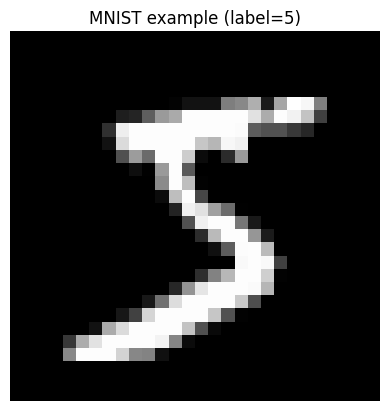

In [3]:
transform = T.Compose([T.ToTensor()])
train_ds = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

x0, y0 = train_ds[0]
plt.imshow(x0.squeeze(0), cmap="gray")
plt.title(f"MNIST example (label={y0})")
plt.axis("off")
plt.show()


### Part 2 — EDA: class balance

In [4]:
n = 20000
y_train = np.array([train_ds[i][1] for i in range(n)])
counts = np.bincount(y_train, minlength=10)

fig = px.bar(x=list(range(10)), y=counts, labels={"x":"Digit", "y":"Count"}, title="MNIST class balance (subset)")
fig.show()


### Part 3 — Mean/variance images (subset)

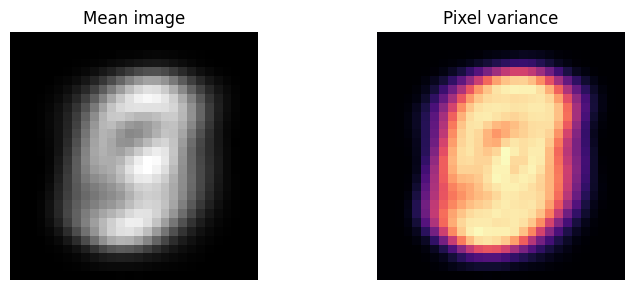

In [5]:
xs = torch.stack([train_ds[i][0] for i in range(n)])  # [n,1,28,28]
mean_img = xs.mean(dim=0).squeeze(0).numpy()
var_img  = xs.var(dim=0).squeeze(0).numpy()

fig, ax = plt.subplots(1,2, figsize=(8,3))
ax[0].imshow(mean_img, cmap="gray"); ax[0].set_title("Mean image"); ax[0].axis("off")
ax[1].imshow(var_img, cmap="magma"); ax[1].set_title("Pixel variance"); ax[1].axis("off")
plt.tight_layout()
plt.show()


### Part 4 — PCA and a baseline classifier

In [ ]:
X = xs.view(n, -1).numpy()
pca = PCA(n_components=20, random_state=0)
Z = pca.fit_transform(X)

fig = px.scatter(x=Z[:,0], y=Z[:,1], color=y_train.astype(str),
                 labels={"x":"PC1", "y":"PC2", "color":"Digit"},
                 title="MNIST PCA (PC1 vs PC2)")
fig.show()

X_train, X_val, y_tr, y_val = train_test_split(X, y_train, test_size=0.2, random_state=0, stratify=y_train)
clf = LogisticRegression(max_iter=200, multi_class="multinomial", solver="lbfgs")
clf.fit(X_train, y_tr)

pred = clf.predict(X_val)
print("Validation accuracy:", accuracy_score(y_val, pred))
show_confusion(y_val, pred, labels=list(range(10)))


### Reflection
1) What does the mean image tell you?
2) Which digits appear most/least separable in PCA?
3) What are plausible sources of bias in MNIST as a benchmark?


## Submission instructions

1. **Run all** cells (Runtime → Run all).
2. Export to PDF:
   - Colab: **File → Print → Save as PDF**.
3. Submit the PDF to Gradescope (**HW## (PDF)**).
4. Optional: download the notebook (`.ipynb`) and submit to **HW## (Notebook – optional)**.
